In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import sklearn

# 1. Loading the dataset
df = pd.read_csv('hospitaldata.csv')
df.head(20)


,encounter_id,patient_nbr,race,gender,age,weight,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,examide,citoglipton,insulin,glyburide_metformin,glipizide_metformin,glimepiride_pioglitazone,metformin_pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),Unknown,_Other,Referral,1,Other,...,No,No,No,No,No,No,No,No,No,No
1,149190,55629189,Caucasian,Female,[10-20),Unknown,Home,Emergency,3,Other,...,No,No,Up,No,No,No,No,Yes,Yes,After30Days
2,64410,86047875,AfricanAmerican,Female,[20-30),Unknown,Home,Emergency,2,Other,...,No,No,No,No,No,No,No,No,Yes,No
3,500364,82442376,Caucasian,Male,[30-40),Unknown,Home,Emergency,2,Other,...,No,No,Up,No,No,No,No,Yes,Yes,No
4,16680,42519267,Caucasian,Male,[40-50),Unknown,Home,Emergency,1,Other,...,No,No,Steady,No,No,No,No,Yes,Yes,No
5,35754,82637451,Caucasian,Male,[50-60),Unknown,Home,Referral,3,Other,...,No,No,Steady,No,No,No,No,No,Yes,After30Days
6,55842,84259809,Caucasian,Male,[60-70),Unknown,Home,Referral,4,Other,...,No,No,Steady,No,No,No,No,Yes,Yes,No
7,63768,114882984,Caucasian,Male,[70-80),Unknown,Home,Emergency,5,Other,...,No,No,No,No,No,No,No,No,Yes,After30Days
8,12522,48330783,Caucasian,Female,[80-90),Unknown,Home,Other,13,Other,...,No,No,Steady,No,No,No,No,Yes,Yes,No
9,15738,63555939,Caucasian,Female,[90-100),Unknown,_Other,Other,12,InternalMedicine,...,No,No,Steady,No,No,No,No,Yes,Yes,No


In [2]:
# describe the dataset
print(df.describe())

       encounter_id   patient_nbr  time_in_hospital  num_lab_procedures  \
count  1.017630e+05  1.017630e+05     101763.000000       101763.000000   
mean   1.652008e+08  5.432965e+07          4.396018           43.095909   
std    1.026410e+08  3.869658e+07          2.985092           19.674220   
min    1.252200e+04  1.350000e+02          1.000000            1.000000   
25%    8.495975e+07  2.341296e+07          2.000000           31.000000   
50%    1.523883e+08  4.550049e+07          4.000000           44.000000   
75%    2.302698e+08  8.754571e+07          6.000000           57.000000   
max    4.438672e+08  1.895026e+08         14.000000          132.000000   

       num_procedures  num_medications  number_outpatient  number_emergency  \
count   101763.000000    101763.000000      101763.000000     101763.000000   
mean         1.339691        16.021835           0.369368          0.197842   
std          1.705792         8.127589           1.267282          0.930485   
min     

In [3]:
print(df.info)

<bound method DataFrame.info of         encounter_id  patient_nbr             race  gender      age    weight  \
0            2278392      8222157        Caucasian  Female   [0-10)   Unknown   
1             149190     55629189        Caucasian  Female  [10-20)   Unknown   
2              64410     86047875  AfricanAmerican  Female  [20-30)   Unknown   
3             500364     82442376        Caucasian    Male  [30-40)   Unknown   
4              16680     42519267        Caucasian    Male  [40-50)   Unknown   
...              ...          ...              ...     ...      ...       ...   
101758     443847548    100162476  AfricanAmerican    Male  [70-80)   Unknown   
101759     443847782     74694222  AfricanAmerican  Female  [80-90)   Unknown   
101760     443854148     41088789        Caucasian    Male  [70-80)   Unknown   
101761     443857166     31693671        Caucasian  Female  [80-90)   Unknown   
101762     443867222    175429310        Caucasian    Male  [70-80)   Unknown

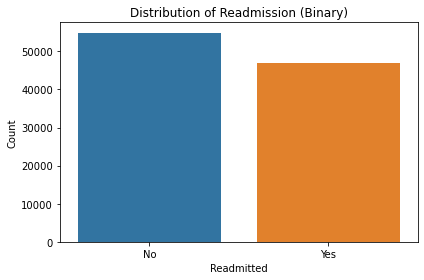

In [4]:

# 2. Transform the target variable to a binary format: "Yes" if readmitted, else "No"
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 'No' if x == 'No' else 'Yes')

# 3. Examine the distribution of the transformed target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='readmitted_binary', data=df)
plt.title('Distribution of Readmission (Binary)')
plt.xlabel('Readmitted')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



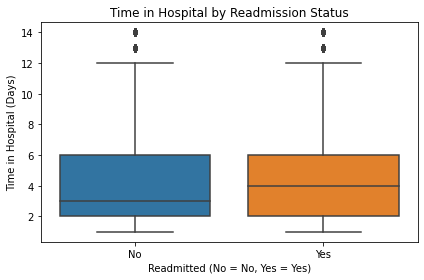

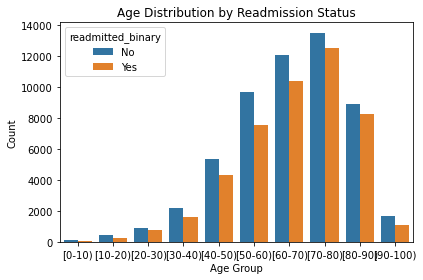

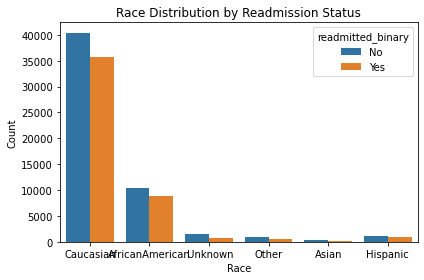

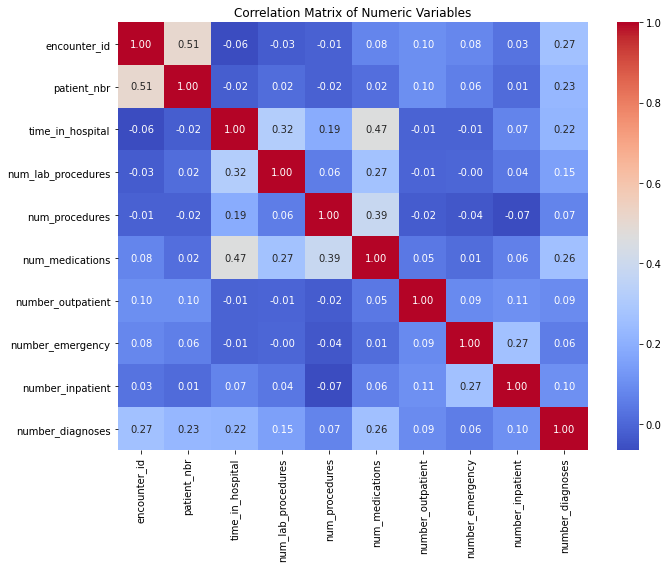

In [5]:
# 4. Visualizing the relationship between the target variable and a few independent variables
# a. Relationship between 'readmitted_binary' and 'time_in_hospital'
plt.figure(figsize=(6, 4))
sns.boxplot(x='readmitted_binary', y='time_in_hospital', data=df)
plt.title('Time in Hospital by Readmission Status')
plt.xlabel('Readmitted (No = No, Yes = Yes)')
plt.ylabel('Time in Hospital (Days)')
plt.tight_layout()
plt.show()

# b. Relationship between 'readmitted_binary' and 'age'
plt.figure(figsize=(6, 4))
sns.countplot(x='age', hue='readmitted_binary', data=df)
plt.title('Age Distribution by Readmission Status')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# c. Relationship between 'readmitted_binary' and 'race'
plt.figure(figsize=(6, 4))
sns.countplot(x='race', hue='readmitted_binary', data=df)
plt.title('Race Distribution by Readmission Status')
plt.xlabel('Race')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# d. Visualizing correlations between numeric variables
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()




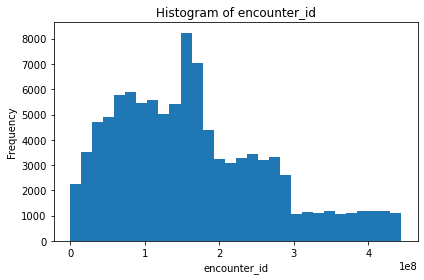

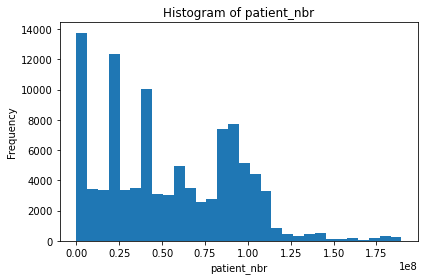

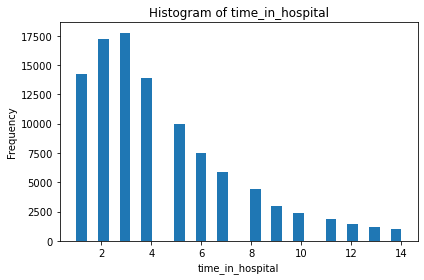

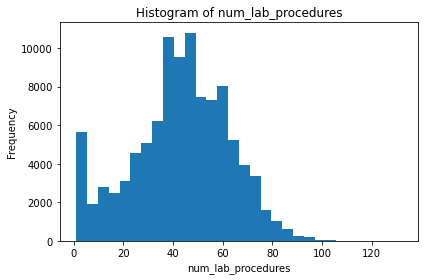

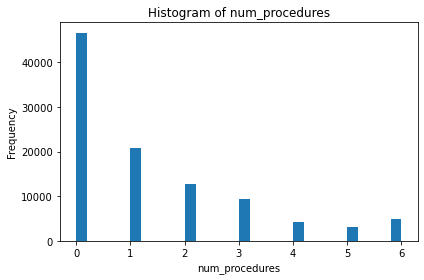

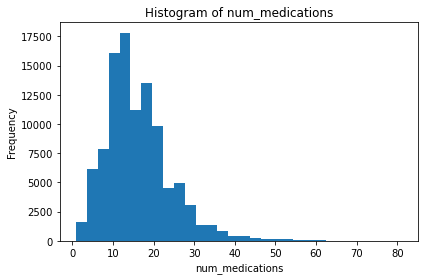

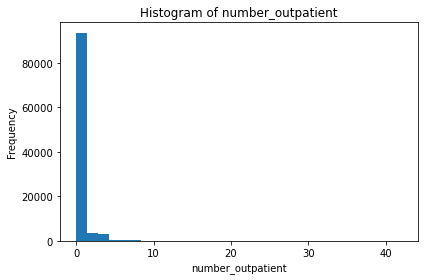

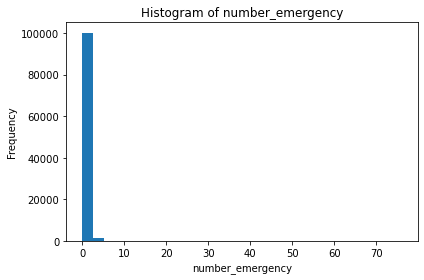

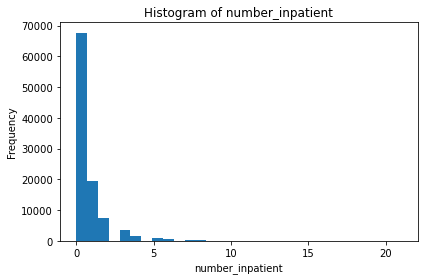

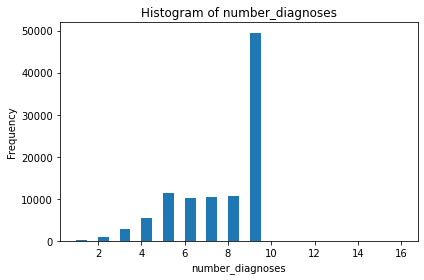

In [6]:
# 6. Visualization: Histograms for numeric variables
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in numeric_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()



<AxesSubplot:title={'center':'Boxplot n_medications'}, xlabel='num_medications'>

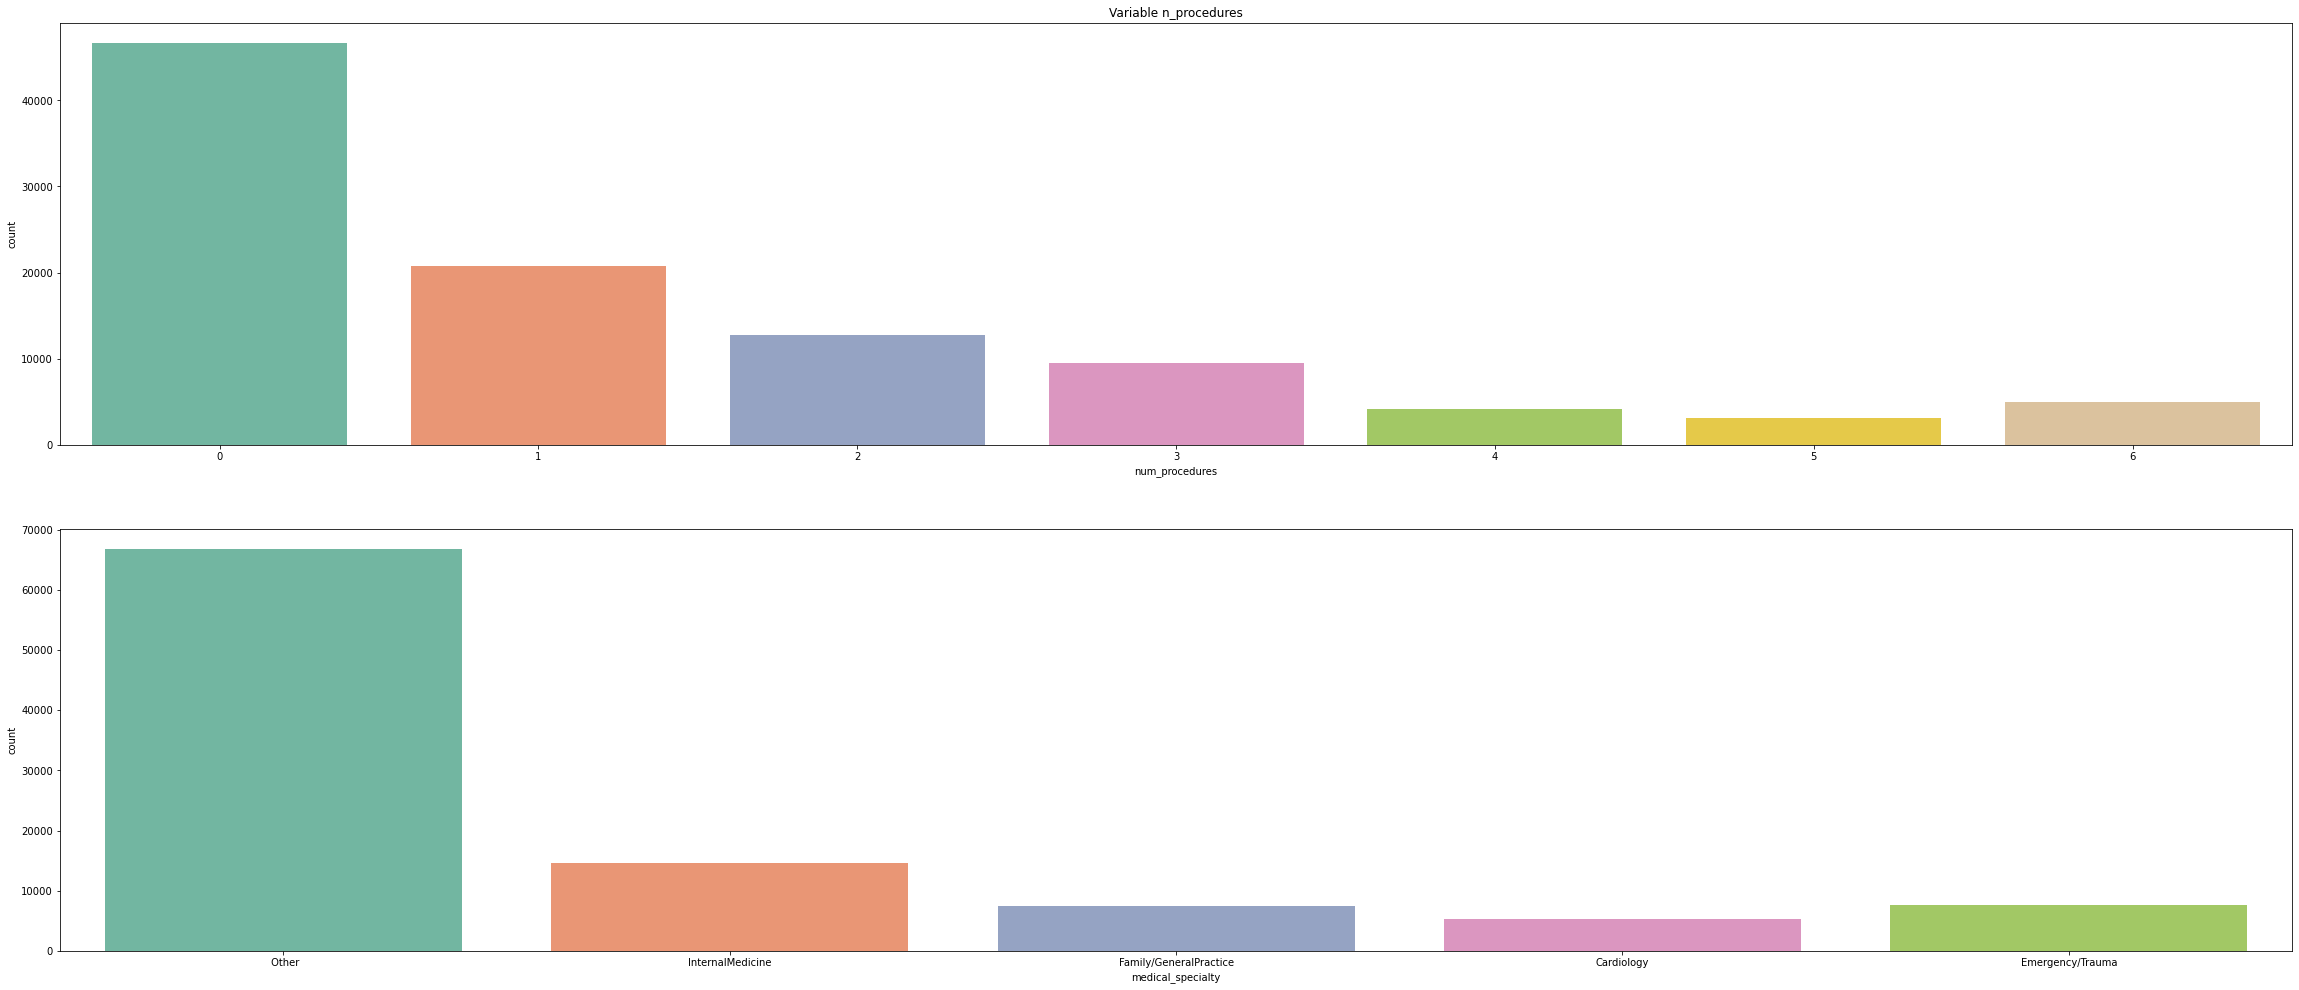

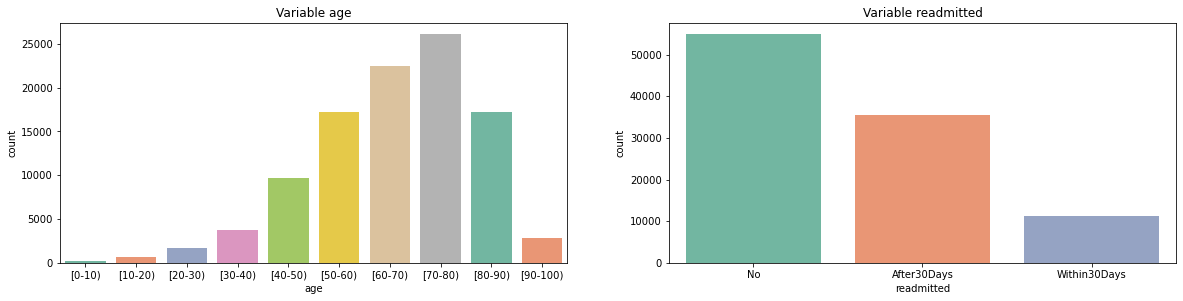

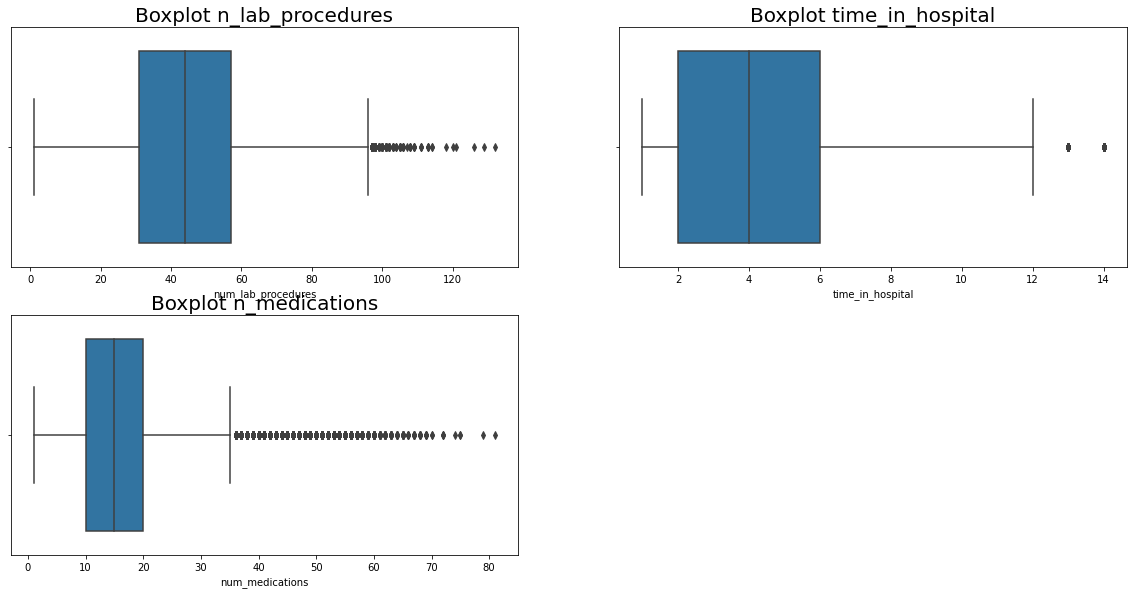

In [7]:
plt.figure(figsize = (40, 45))

plt.subplot(5, 1, 1)
plt.gca().set_title('Variable n_procedures')
sns.countplot(x = 'num_procedures', palette = 'Set2', data = df)

plt.subplot(5, 1, 2)
sns.countplot(x = 'medical_specialty', palette = 'Set2', data = df)

plt.figure(figsize = (20, 15))

plt.subplot(3, 2, 1)
plt.gca().set_title('Variable age')
sns.countplot(x = 'age', palette = 'Set2', data = df)


plt.subplot(3, 2, 2)
plt.gca().set_title('Variable readmitted')
sns.countplot(x = 'readmitted', palette = 'Set2', data = df)


plt.figure(figsize = (20, 15))

plt.subplot(3, 2, 1)
plt.title("Boxplot n_lab_procedures", fontdict = {'fontsize': 20})
sns.boxplot(x=df["num_lab_procedures"])

plt.subplot(3, 2, 2)
plt.title("Boxplot time_in_hospital", fontdict = {'fontsize': 20})
sns.boxplot(x=df["time_in_hospital"])

plt.subplot(3, 2, 3)
plt.title("Boxplot n_medications", fontdict = {'fontsize': 20})
sns.boxplot(x=df["num_medications"])

<AxesSubplot:xlabel='readmitted', ylabel='number_emergency'>

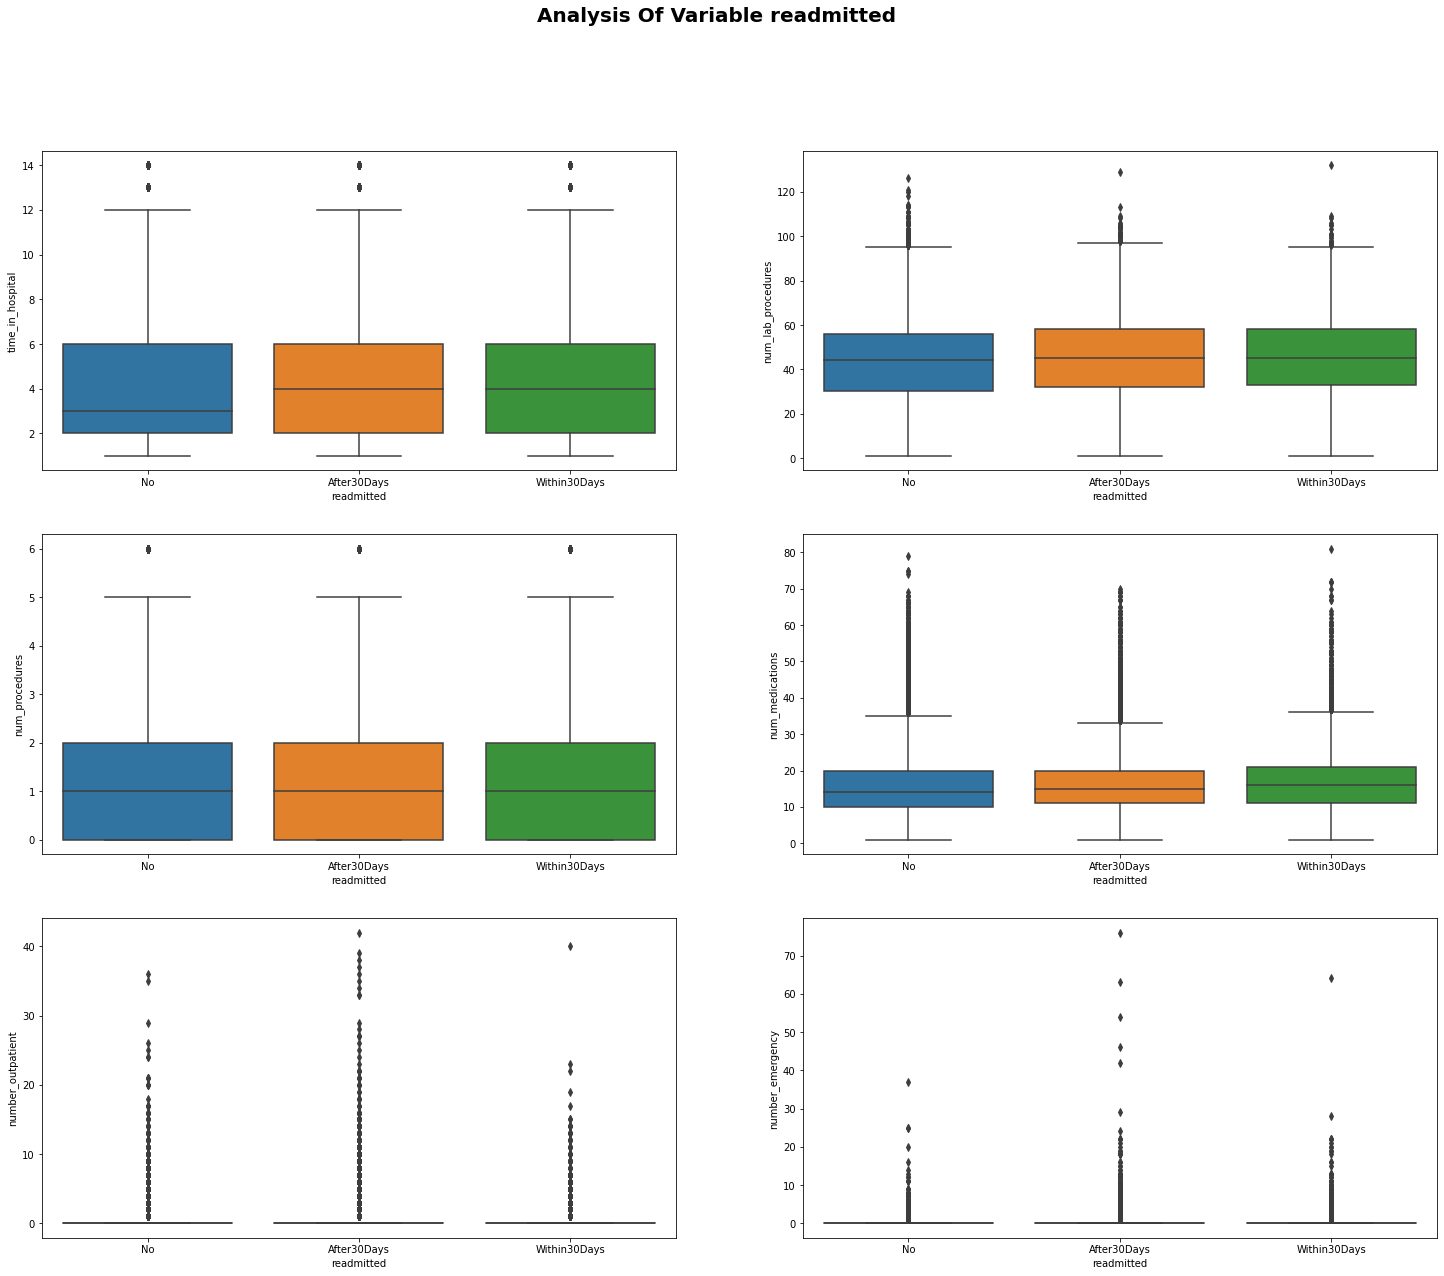

In [8]:
plt.figure(figsize = (25, 20))
plt.suptitle("Analysis Of Variable readmitted",fontweight="bold", fontsize=20)

plt.subplot(3,2,1)
sns.boxplot(x="readmitted", y="time_in_hospital", data=df)

plt.subplot(3,2,2)
sns.boxplot(x="readmitted", y="num_lab_procedures", data=df)

plt.subplot(3,2,3)
sns.boxplot(x="readmitted", y="num_procedures", data=df)

plt.subplot(3,2,4)
sns.boxplot(x="readmitted", y="num_medications", data=df)

plt.subplot(3,2,5)
sns.boxplot(x="readmitted", y="number_outpatient", data=df)

plt.subplot(3,2,6)
sns.boxplot(x="readmitted", y="number_emergency", data=df)

In [9]:
# 5. Prepare the data for logistic regression:
#    a. Convert categorical variables into dummy/indicator variables.
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('readmitted')  # Exclude 'readmitted' column from encoding
categorical_cols.remove('readmitted_binary')  # Exclude 'readmitted_binary' from encoding

# Perform one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

#    b. Define features (X) and the new binary target (y).
X = df_encoded.drop(['readmitted', 'readmitted_binary'], axis=1)
y = df_encoded['readmitted_binary']



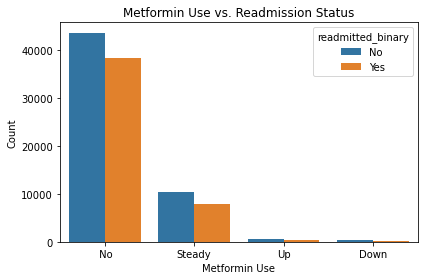

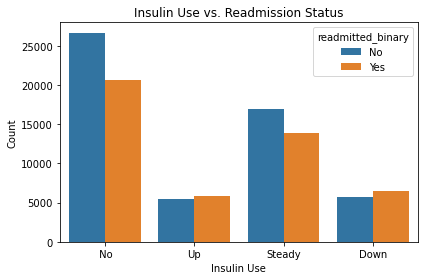

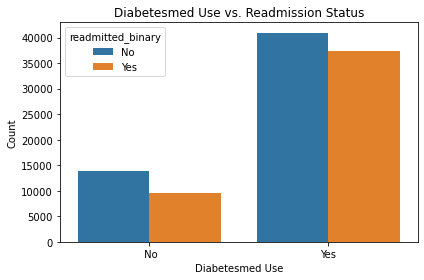

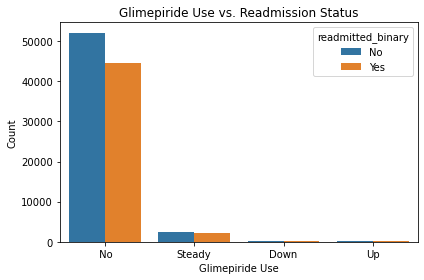

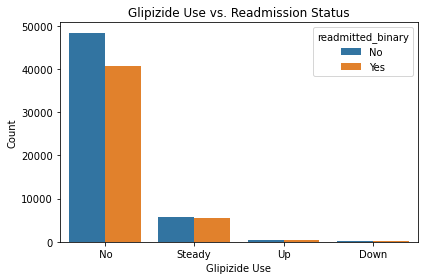

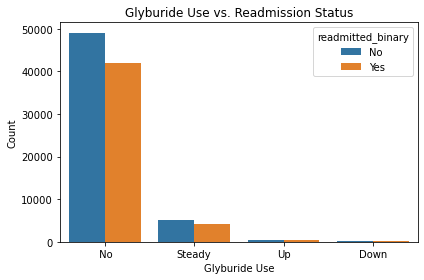

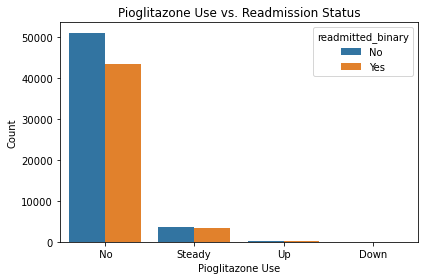

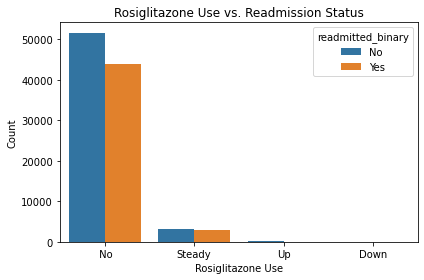

In [10]:
# Analyzing the Relationship Between Readmission and Medication Use:
# List of medication columns to analyze
medications = ['metformin', 'insulin', 'diabetesMed', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone']

# Visualizing the relationship between medication use and readmission
for med in medications:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=med, hue='readmitted_binary', data=df)
    plt.title(f'{med.capitalize()} Use vs. Readmission Status')
    plt.xlabel(f'{med.capitalize()} Use')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


In [11]:
# checking the medicines impact on the readmission of patient
# Transform the 'readmitted' column into a binary column: 'No' -> 0, 'Yes' -> 1
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 0 if x == 'No' else 1)

# List of medication columns to analyze
medications = ['metformin', 'insulin', 'diabetesMed', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone']

# evaluate the efficiency of these medications in predicting readmission using Logistic Regression model for each medication.

medication_accuracies = {}

# Iterate over each medication to build and evaluate the model
for med in medications:
    df[med] = df[med].apply(lambda x: 1 if x == 'Yes' else 0)  # Convert 'Yes' to 1, 'No' to 0

    # Create features and target
    X = df[[med]]
    y = df['readmitted_binary']
    
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Create and train a logistic regression model
    lr = LogisticRegression(max_iter=1000, solver='liblinear')
    lr.fit(X_train, y_train)
    
    # Make predictions
    y_pred = lr.predict(X_test)
    
    # Evaluate the model and store the accuracy
    accuracy = accuracy_score(y_test, y_pred)
    medication_accuracies[med] = accuracy

# Sort the medications by accuracy
sorted_medication_accuracies = sorted(medication_accuracies.items(), key=lambda x: x[1], reverse=True)

# Display the comparison
print("\nMedication Use vs Readmission Efficiency (Accuracy):")
for med, acc in sorted_medication_accuracies:
    print(f'{med.capitalize()}: {acc:.4f}')



Medication Use vs Readmission Efficiency (Accuracy):
Metformin: 0.5364
Insulin: 0.5364
Diabetesmed: 0.5364
Glimepiride: 0.5364
Glipizide: 0.5364
Glyburide: 0.5364
Pioglitazone: 0.5364
Rosiglitazone: 0.5364


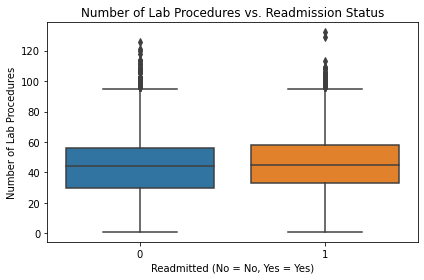

In [12]:
# Exploring the Impact of Number of Lab Procedures on Readmission:
# Visualizing the relationship between the number of lab procedures and readmission
plt.figure(figsize=(6, 4))
sns.boxplot(x='readmitted_binary', y='num_lab_procedures', data=df)
plt.title('Number of Lab Procedures vs. Readmission Status')
plt.xlabel('Readmitted (No = No, Yes = Yes)')
plt.ylabel('Number of Lab Procedures')
plt.tight_layout()
plt.show()

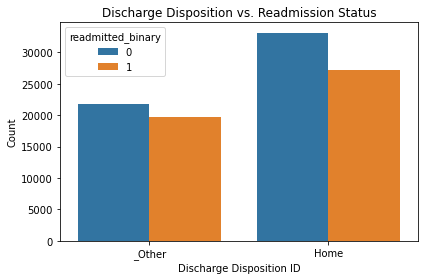

In [13]:

# Visualizing the relationship between discharge disposition and readmission risk
plt.figure(figsize=(6, 4))
sns.countplot(x='discharge_disposition_id', hue='readmitted_binary', data=df)
plt.title('Discharge Disposition vs. Readmission Status')
plt.xlabel('Discharge Disposition ID')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [14]:
# 6. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 7. Create a preprocessing pipeline: scale numerical features and one-hot encode categorical features
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[ 
        ('num', StandardScaler(), numeric_cols),  # Apply scaling to numerical columns
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)  # Apply one-hot encoding to categorical columns
    ])



In [15]:
# 8. Create a logistic regression model pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, solver='liblinear'))  # Logistic Regression
])

# 9. Train the logistic regression model
model.fit(X_train, y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['rosiglitazone']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, solver='liblinear'))])

In [16]:
# 10. Make predictions on the test set
y_pred = model.predict(X_test)



In [17]:
# 11. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\nLogistic Regression Accuracy: {:.2f}".format(accuracy))
print("\nClassification Report:")
print(classification_rep)




Logistic Regression Accuracy: 0.54

Classification Report:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70     16376
           1       0.00      0.00      0.00     14153

    accuracy                           0.54     30529
   macro avg       0.27      0.50      0.35     30529
weighted avg       0.29      0.54      0.37     30529



C:\Users\nc597\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


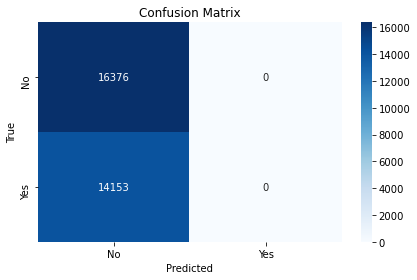

In [18]:
# 12. Visualization: Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

C:\Users\nc597\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



Model 1 (Medication Features) - Accuracy: 0.5364080055029644

Model 1 (Medication Features) - Classification Report:
               precision    recall  f1-score   support

           0       0.54      1.00      0.70     16376
           1       0.00      0.00      0.00     14153

    accuracy                           0.54     30529
   macro avg       0.27      0.50      0.35     30529
weighted avg       0.29      0.54      0.37     30529


Model 2 (All Features) - Accuracy: 0.6397851223426906

Model 2 (All Features) - Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.74      0.69     16376
           1       0.64      0.52      0.57     14153

    accuracy                           0.64     30529
   macro avg       0.64      0.63      0.63     30529
weighted avg       0.64      0.64      0.63     30529



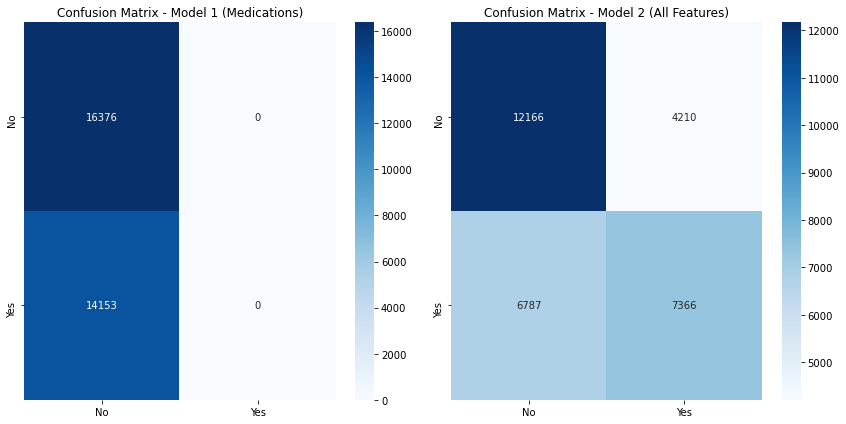

In [19]:
# Transform 'readmitted' column into a binary variable: 'No' -> 0, 'Yes' -> 1
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 0 if x == 'No' else 1)

# List of medication columns to use for Model 1
medications = ['metformin', 'insulin', 'diabetesMed', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone']

# Convert medication columns to binary (0 for 'No' and 1 for 'Yes')
for med in medications:
    df[med] = df[med].apply(lambda x: 1 if x == 'Yes' else 0)  # Convert 'Yes' to 1, 'No' to 0

# 1. Prepare Model 1: Logistic Regression using only medication features
X_med = df[medications]  # Only medication features
y = df['readmitted_binary']  # Target variable

# Split data into training and testing sets for Model 1
X_train_med, X_test_med, y_train, y_test = train_test_split(X_med, y, test_size=0.3, random_state=42)

# Train the logistic regression model for medications only
lr_med = LogisticRegression(max_iter=1000, solver='liblinear')
lr_med.fit(X_train_med, y_train)

# Predictions for Model 1
y_pred_med = lr_med.predict(X_test_med)

# Evaluate Model 1
accuracy_med = accuracy_score(y_test, y_pred_med)
classification_rep_med = classification_report(y_test, y_pred_med)
conf_matrix_med = confusion_matrix(y_test, y_pred_med)

# 2. Prepare Model 2: Logistic Regression using all available features
# We need to handle categorical variables by one-hot encoding them and scale numerical features
# Define all features (X) excluding the target columns
X_all = df.drop(columns=['readmitted', 'readmitted_binary'])  # All features except target columns

# Preprocessing: One-hot encode categorical features and scale numerical features
categorical_cols = X_all.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_all.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create a column transformer that applies OneHotEncoder to categorical columns and StandardScaler to numerical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),  # Apply scaling to numerical columns
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)  # Apply one-hot encoding to categorical columns
    ])

# Create a logistic regression model pipeline for all features
model_all = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, solver='liblinear'))  # Logistic Regression
])

# Split data into training and testing sets for Model 2
X_train_all, X_test_all, y_train, y_test = train_test_split(X_all, y, test_size=0.3, random_state=42)

# Train the logistic regression model for all features
model_all.fit(X_train_all, y_train)

# Predictions for Model 2
y_pred_all = model_all.predict(X_test_all)

# Evaluate Model 2
accuracy_all = accuracy_score(y_test, y_pred_all)
classification_rep_all = classification_report(y_test, y_pred_all)
conf_matrix_all = confusion_matrix(y_test, y_pred_all)

# Display comparison of results
print("\nModel 1 (Medication Features) - Accuracy:", accuracy_med)
print("\nModel 1 (Medication Features) - Classification Report:\n", classification_rep_med)

print("\nModel 2 (All Features) - Accuracy:", accuracy_all)
print("\nModel 2 (All Features) - Classification Report:\n", classification_rep_all)

# Plotting confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.heatmap(conf_matrix_med, annot=True, fmt='g', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], ax=axes[0])
axes[0].set_title("Confusion Matrix - Model 1 (Medications)")

sns.heatmap(conf_matrix_all, annot=True, fmt='g', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], ax=axes[1])
axes[1].set_title("Confusion Matrix - Model 2 (All Features)")

plt.tight_layout()
plt.show()


Model 3 (Combined Features) - Accuracy: 0.6397851223426906

Model 3 (Combined Features) - Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.74      0.69     16376
           1       0.64      0.52      0.57     14153

    accuracy                           0.64     30529
   macro avg       0.64      0.63      0.63     30529
weighted avg       0.64      0.64      0.63     30529



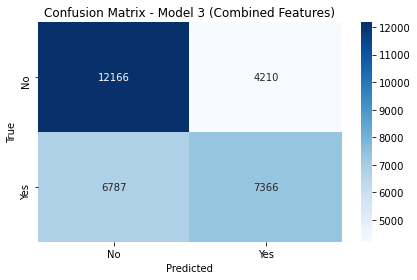

In [20]:
# Transform 'readmitted' column into a binary variable: 'No' -> 0, 'Yes' -> 1
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 0 if x == 'No' else 1)

# List of medication columns to use for Model 1
medications = ['metformin', 'insulin', 'diabetesMed', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone']

# Convert medication columns to binary (0 for 'No' and 1 for 'Yes')
for med in medications:
    df[med] = df[med].apply(lambda x: 1 if x == 'Yes' else 0)  # Convert 'Yes' to 1, 'No' to 0

# 1. Merge both medication features and all other features for Model 3
X_combined = df.drop(columns=['readmitted', 'readmitted_binary'])  # All features except target columns
y = df['readmitted_binary']  # Target variable

# Preprocessing: One-hot encode categorical features and scale numerical features
categorical_cols = X_combined.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_combined.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create a column transformer that applies OneHotEncoder to categorical columns and StandardScaler to numerical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),  # Apply scaling to numerical columns
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)  # Apply one-hot encoding to categorical columns
    ])

# Create a logistic regression model pipeline for the combined features
model_combined = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, solver='liblinear'))  # Logistic Regression
])

# Split data into training and testing sets for the combined model
X_train_combined, X_test_combined, y_train, y_test = train_test_split(X_combined, y, test_size=0.3, random_state=42)

# Train the logistic regression model for the combined features
model_combined.fit(X_train_combined, y_train)

# Predictions for Model 3 (combined features)
y_pred_combined = model_combined.predict(X_test_combined)

# Evaluate Model 3
accuracy_combined = accuracy_score(y_test, y_pred_combined)
classification_rep_combined = classification_report(y_test, y_pred_combined)
conf_matrix_combined = confusion_matrix(y_test, y_pred_combined)

# Display the results
print("\nModel 3 (Combined Features) - Accuracy:", accuracy_combined)
print("\nModel 3 (Combined Features) - Classification Report:\n", classification_rep_combined)

# Plotting confusion matrix for Model 3
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_combined, annot=True, fmt='g', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title("Confusion Matrix - Model 3 (Combined Features)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

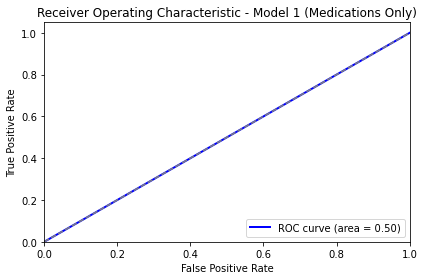

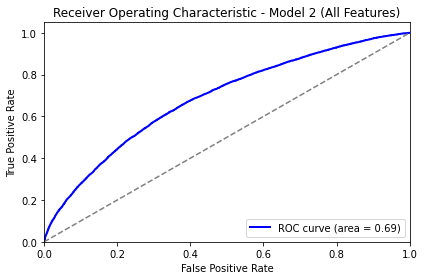

In [21]:

# 5. Plotting ROC curve for both models (Model 1: Medications Only, Model 2: All Features)

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Model 1: ROC Curve (Medications Only)
y_pred_prob_med = lr_med.predict_proba(X_test_med)[:, 1]  # Probability of positive class
fpr_med, tpr_med, _ = roc_curve(y_test, y_pred_prob_med)
auc_score_med = auc(fpr_med, tpr_med)

# Model 2: ROC Curve (All Features)
y_pred_prob_all = model_all.predict_proba(X_test_all)[:, 1]  # Probability of positive class
fpr_all, tpr_all, _ = roc_curve(y_test, y_pred_prob_all)
auc_score_all = auc(fpr_all, tpr_all)

# Function to plot the ROC curve
def plot_roc_curve(fpr, tpr, auc_score, model_name):
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic - {model_name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# Plotting the ROC curves for both models
plot_roc_curve(fpr_med, tpr_med, auc_score_med, 'Model 1 (Medications Only)')
plot_roc_curve(fpr_all, tpr_all, auc_score_all, 'Model 2 (All Features)')
